# Analysis of Trained Models

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# System imports
from pathlib import Path
import sys
from datetime import date
from collections import defaultdict
import json

# Plotting imports
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Scientific imports
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import zscore, spearmanr
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

# NN imports
import torch
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
SRC_PATH = ROOT / 'src'
sys.path.append(str(ROOT))
sys.path.append(str(SRC_PATH))

# Custom imports
from src.environments import TAMTask, MotionTask, load_motion_from_image, load_tam_from_image
from src.train_test_utils import plot_dataset, plot_training_curves
from src.networks import TAMNet
from src.utils import load_params

In [31]:
# Plotting settings
custom_palette = sns.color_palette(["#E74C3C", "#2ECC71"]) # a custom palette with red and green
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False
}
sns.set_theme(
    font_scale=1,
    style='white',
    context='poster',
    font='Arial',
    rc=custom_params
)

In [9]:
# Set directories
# Figures
today = date.today().strftime('%m-%d-%Y')
FIG_DIR = ROOT / 'figures' / today
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Network
MODEL_DIR = ROOT / 'data' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Stimuli
STIM_DIR = ROOT / 'data' / 'stimuli' / "TAM_basic"

In [10]:
# Load parameters
params = load_params(str(ROOT / 'parameters.json'))
exp_params = params["EXPERIMENT"]
env_params = params['TASK']
net_params = params['NETWORK']

In [19]:
motion_dirs = ["horizontal"]
box_shapes = ["square", "circle", "triangle"]
img_size = 32
batch_size = 128
seq_len = 10

# Create environments and datasets
tam_test_datasets = defaultdict()
motion_test_datasets = defaultdict()
tam_types = ["tam", "outline"]
motion_types = ["cnt", "track"]

for bs in box_shapes:
    for tt in tam_types:
        for md in motion_dirs:
            print(bs, tt, md)
            if tt == "tam":
                _path = STIM_DIR
            else:
                _path = STIM_DIR.parent / "TAM_outline"

            stimuli = load_tam_from_image(img_size, stim_type=tt, stim_path=_path)
            env = TAMTask(
                box_shape=bs,
                stimuli=stimuli,
                stim_type=tt,
                stim_ori=md,
                dt=env_params["dt"],
                sigma=0.01,
                img_size=img_size
            )
            env.reset(no_step=True)

            # Generate dataset object
            dataset = ngym.Dataset(
                env,
                batch_size=batch_size,
                seq_len=seq_len
            )

            # Add dataset to dictionary
            tam_test_datasets[f'{bs}-{tt}-{md}'] = env
            tam_test_datasets[f'{bs}-{tt}-{md}'] = dataset

square tam horizontal
square outline horizontal
circle tam horizontal
circle outline horizontal
triangle tam horizontal
triangle outline horizontal


In [25]:
device = torch.device(net_params["device"])

net = TAMNet(
    dataset=tam_test_datasets["square-tam-horizontal"],
    hidden_size=256,
    output_size=tam_test_datasets["square-tam-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)

# Load the trained weights
model = net.RNN
model.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_TAM-basic_256_VSS_only_last_new.pt'))
model.eval()

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=1024, out_features=256, bias=True)
    (h2h): Linear(in_features=256, out_features=256, bias=True)
  )
  (fc): Linear(in_features=256, out_features=6, bias=True)
)

In [26]:
# Test on other environments
test_accuracies = defaultdict()
test_activities = defaultdict()
infos = defaultdict()
for et, dataset in tam_test_datasets.items():
    info, activity, test_acc = net.test_rnn(500, dataset)
    infos[et] = info
    test_accuracies[et] = test_acc
    test_activities[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-tam-horizontal = 1.0
Accuracy on square-outline-horizontal = 1.0
Accuracy on circle-tam-horizontal = 0.72
Accuracy on circle-outline-horizontal = 0.702
Accuracy on triangle-tam-horizontal = 0.478
Accuracy on triangle-outline-horizontal = 0.444


# Plot accuracies

In [27]:
accuracy_labels = {
    "Square": test_accuracies["square-tam-horizontal"],
    "Square Outline": test_accuracies["square-outline-horizontal"],
    "Circle": test_accuracies["circle-tam-horizontal"],
    "Circle Outline": test_accuracies["circle-outline-horizontal"],
    "Triangle": test_accuracies["triangle-tam-horizontal"],
    "Triangle Outline": test_accuracies["triangle-outline-horizontal"],
}

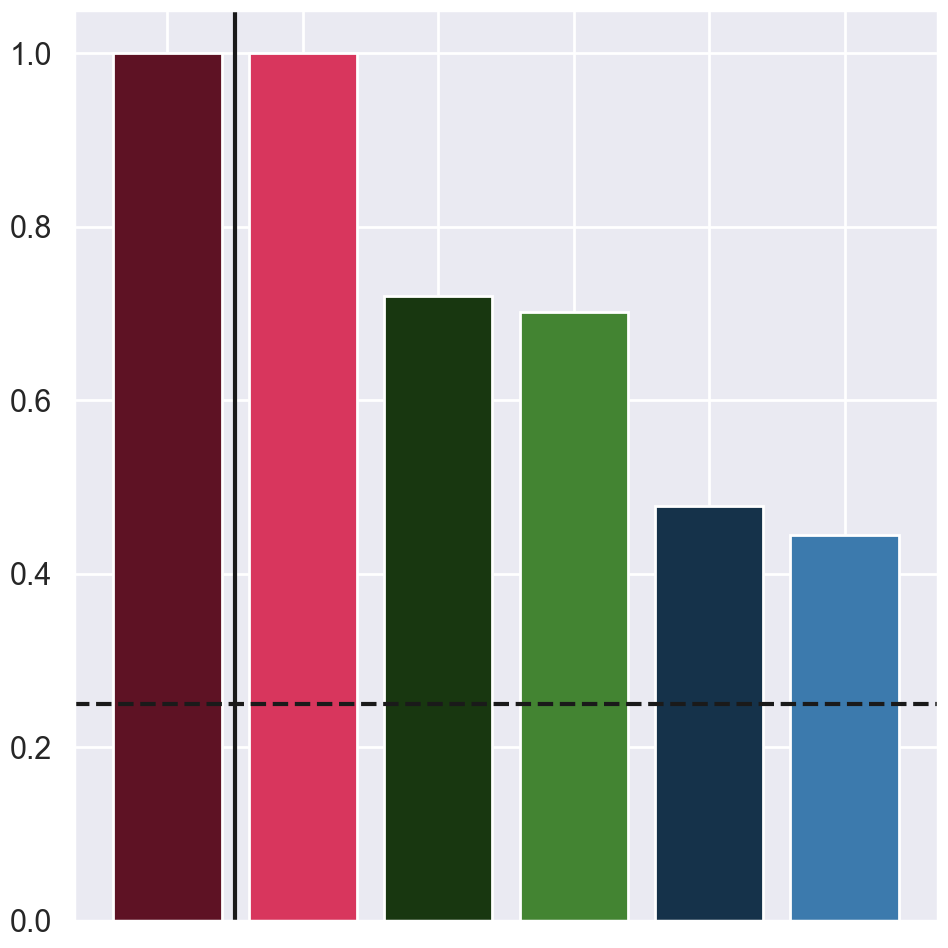

In [28]:
# Plot test accuracy
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# fig.suptitle("Test accuracy")

# Define colors
colors_high_sat = sns.husl_palette(3, s=0.8, l=0.2)  # 3 colors with high saturation
colors_low_sat = sns.husl_palette(3, s=0.8, l=0.5)  # 3 colors with low saturation

# Create a new list by interweaving the two color lists
colormap = [val for pair in zip(colors_high_sat, colors_low_sat) for val in pair]


ax.bar(accuracy_labels.keys(), accuracy_labels.values(), color=colormap)
plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_xlabel('')
ax.set_xticklabels([])
ax.set_ylabel('')
ax.axhline(y=0.25, color='k', linestyle='--')
ax.axvline(x=0.5, color='k', linestyle='-')
plt.tight_layout()
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_test_accuracy_256.png')

In [29]:
# Define PCA to extract 2 components
pca = PCA(n_components=2)
activity = test_activities["square-tam-horizontal"]

# Concatenate activity for PCA
all_activity = np.concatenate(list(activity), axis=0)
print("Shape of the original activity: (Number of trials, )", activity.shape)
print("Shape of each trial's activity: (Trial time points, Neurons)", activity[0].shape)
print('Shape of the concatenated activity: (Time points, Neurons): ', all_activity.shape)

# Run PCA on the concatenated data data
pca.fit(all_activity)  # activity (Time points, Neurons)

# Find the transform to low-dimension
activity_pc = pca.transform(all_activity)
print('Shape of the projected activity: (Time points, PCs): ', activity_pc.shape)

# Save important variables
n_trials = activity.shape[0]
n_timepoints = activity[0].shape[0]
n_all_neurons = activity[0].shape[1]

print('Number of trials: ', n_trials)
print('Number of time points: ', n_timepoints)
print('Number of neurons: ', n_all_neurons)

Shape of the original activity: (Number of trials, ) (500,)
Shape of each trial's activity: (Trial time points, Neurons) (10, 256)
Shape of the concatenated activity: (Time points, Neurons):  (5000, 256)
Shape of the projected activity: (Time points, PCs):  (5000, 2)
Number of trials:  500
Number of time points:  10
Number of neurons:  256


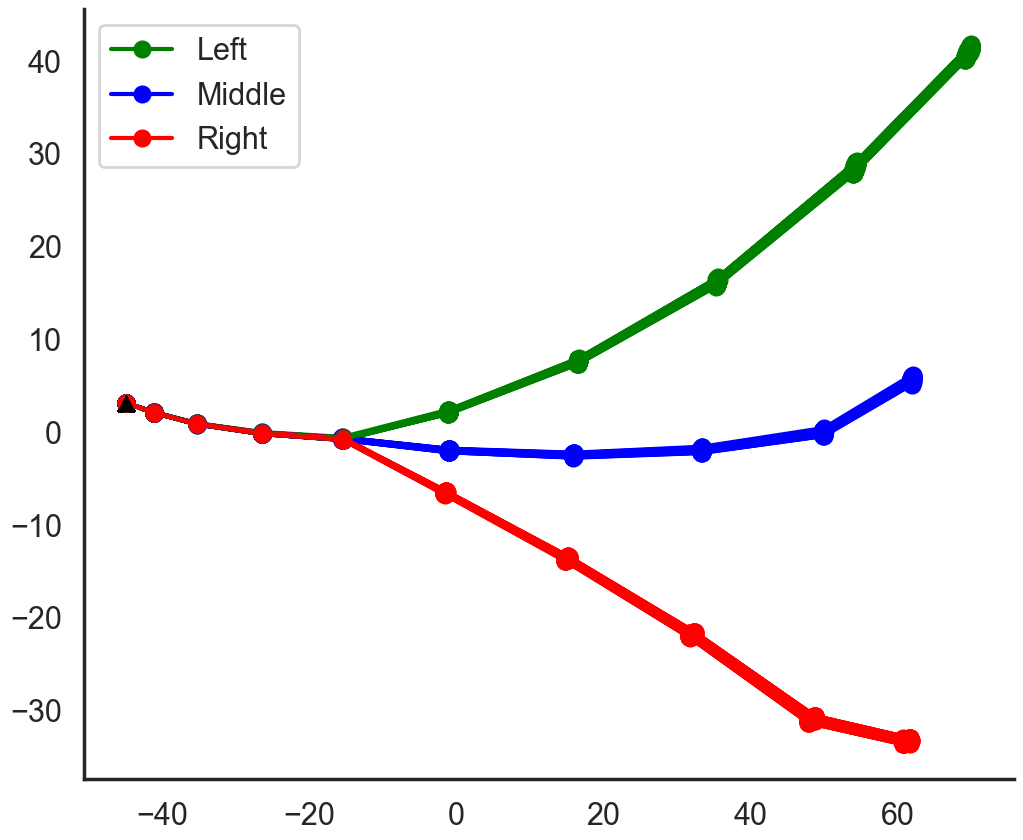

In [34]:
fig, ax = plt.subplots(figsize=(12, 10))
trial_infos = infos["square-tam-horizontal"]

# Create empty lists to hold legend handles and labels
handles = []
labels = []

# Go through trials
for t in range(n_trials):

    # Transform each trial
    activity_pc = pca.transform(activity[t])  # (Time points, PCs)

    # Select this trial's ground truth
    trial = trial_infos[t]
    if trial['ground_truth'] == 1:
        motion = 'Right'
        color = 'red'
    elif trial['ground_truth'] == 2:
        motion = 'Middle'
        color = 'blue'
    elif trial["ground_truth"] == 3:
        motion = 'Left'
        color='green'

    # Plot the PC activity
    p, = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

    # If this is the first time this type of motion is plotted, add it to the legend
    if motion not in labels:
        handles.append(p)
        labels.append(motion)

    # Plot the beginning of a trial with a special symbol
    _ = ax.plot(activity_pc[0, 0], activity_pc[0, 1], '^', color='black')

# Add a legend using the handles and labels lists
plt.legend(handles, labels)

# Change names
# ax.set_title(f'PCA')
# ax.set_xlabel('PC 1')
# ax.set_ylabel('PC 2')

plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_256.png')

In [35]:
# Binning time points
n_bins = 3
bin_size = n_timepoints // n_bins
bins = np.histogram(np.arange(n_timepoints), n_bins)
bin_edges = np.floor(bins[1]).astype(int)

# Define PCA with 2 components
n_comps = 2
pca = PCA(n_components=n_comps)

# Initiate variables to keep track of top PCA neurons
n_top = 10  # number of top neurons with the highest weights in PCA
top_neurons = np.zeros((n_comps, n_top, n_bins))

# Loop through time bins
for i, tb in enumerate(bin_edges[:-1]):

    # Select activity across all trials and neurons for only this time bin
    bin_activity = np.concatenate([ac[tb: tb + bin_size] for ac in activity], axis=0)

    # Run PCA
    pca.fit(bin_activity)

    # Extract loadings
    loadings = pca.components_

    # Get index of top k neurons
    for pc in range(n_comps):
        neurons = np.argpartition(loadings[pc], -n_top)[-n_top:]
        top_neurons[pc, :, i] = neurons

In [36]:
# Gather the data from neurons of interest in a dataframe for easier plotting
data = {"NEURON":[], "TRIAL": [], "TIMEPOINT": [], "ACTIVITY": [], "TRIAL_TYPE": []}

# Find the highest activity neurons (without duplicates)
neurons = np.unique(top_neurons.flatten()).astype(int)

# Get the timeseries of activities
for n, neuron in enumerate(neurons):

    # Find the timeseries of activity of this neuron in all trials
    for trial in range(n_trials):
        for tp in range(n_timepoints):

            ac = activity[trial][tp, neuron]

            # Save to data
            data["NEURON"].append(neuron)
            data["TRIAL"].append(trial + 1)
            data["TIMEPOINT"].append(tp + 1)
            data["ACTIVITY"].append(ac)

            if trial_infos[trial]["ground_truth"] == 1:
                tt = "Right"
            elif trial_infos[trial]["ground_truth"] == 2:
                tt = "Mid"
            else:
                tt = "Left"
            data["TRIAL_TYPE"].append(tt)

# Turn into dataframe
df = pd.DataFrame(data)
df.head()

,NEURON,TRIAL,TIMEPOINT,ACTIVITY,TRIAL_TYPE
0,0,1,1,0.456590,Left
1,0,1,2,3.609207,Left
2,0,1,3,5.582962,Left
3,0,1,4,6.654502,Left
4,0,1,5,6.994461,Left


In [ ]:
# Visualizing the activity of highest-loading neurons
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
custom_pal = sns.color_palette("Paired", len(df.NEURON.unique()))
fig.suptitle("Timeseries of 52 top PC Neurons")

# Normalize activity
plt_df = df.copy()
for neuron in neurons:
    plt_df.loc[df.NEURON == neuron, "ACTIVITY"] = zscore(plt_df.loc[df.NEURON == neuron, "ACTIVITY"])

# Palette
custom_pal = sns.dark_palette("gray", n_colors=len(neurons))

# Plot the normalized activity
_plot = sns.lineplot(
    data=plt_df,
    x="TIMEPOINT",
    y="ACTIVITY",
    hue="NEURON",
    palette=custom_pal,
    ax=axes
)
axes.set_ylabel("Normalized Activity")
_plot.legend_.remove()

# Change properties
# for i in range(2):
axes.set_xlabel("Time")
x_ticks = np.arange(0, 550, 100)
axes.set_xticklabels(x_ticks)
axes.axvline(x=5, color='r', ls='--')
axes.axvline(x=9, color='b', ls='--')

plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_timeseries.png')